โครงสร้างมิติภาพต้นฉบับ: 401 x 338 พิกเซล


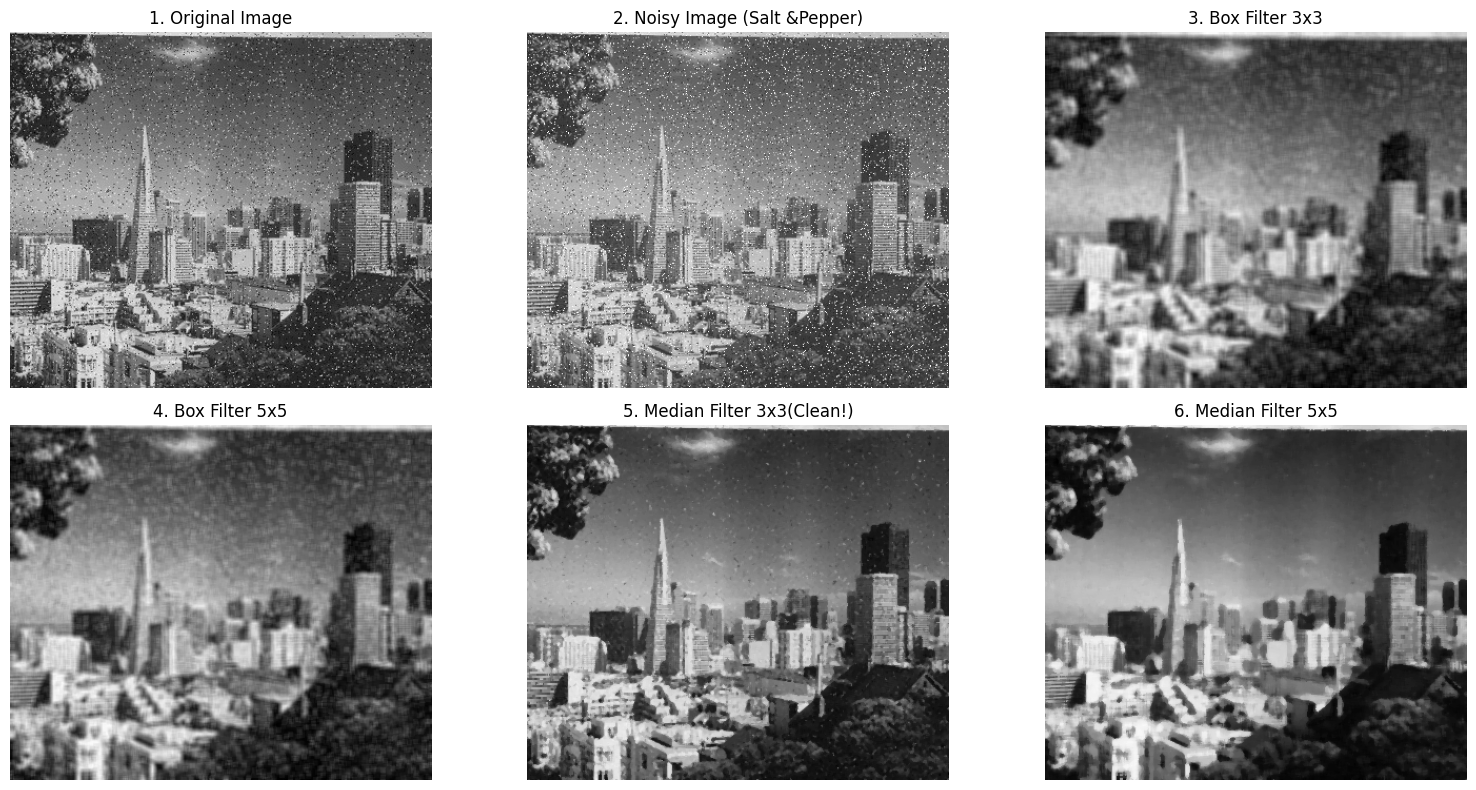

In [8]:
# guided_noise_filtration.py
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 1. อ่านภาพต้นฉบับเข้ามาและแปลงเป็น Grayscale 8-bit
img = cv2.imread('imgnoise.jpg', cv2.IMREAD_GRAYSCALE) # ใช้คำสั่ง cv2.imread เพื่อโหลดรูปภาพเข้ามาในหน่วยความจำ
if img is None:
    raise FileNotFoundError("ไม่พบไฟล์รูปภาพ 'source.png' กรุณาตรวจสอบตําแหน่งไฟล์")
h, w = img.shape
print(f"โครงสร้างมิติภาพต้นฉบับ: {w} x {h} พิกเซล")

# 2. จําลองสร้างสัญญาณรบกวนแบบ Salt & Pepper (อัตราความหนาแน่นร้อยละ 5 ของพื้นที่พิกเซล)
noisy_img = img.copy()
total_pixels = h * w
num_noise_pixels = int(0.05 * total_pixels)
# สุ่มตีกรอบพิกัดและใส่จุดเกลือสีขาวสว่างจ้า (255)
for _ in range(num_noise_pixels // 2):
    r_idx = np.random.randint(0, h)
    c_idx = np.random.randint(0, w)
    noisy_img[r_idx, c_idx] = 255
# สุ่มตีกรอบพิกัดและใส่จุดพริกไทยสีดําสนิท (0)
for _ in range(num_noise_pixels // 2):
    r_idx = np.random.randint(0, h)
    c_idx = np.random.randint(0, w)

noisy_img[r_idx, c_idx] = 0
# 3. ขจัดสัญญาณรบกวนด้วยตัวกรองเฉลี่ย (Box Filter) ขนาดหน้ากาก 3x3 และ 5x5
blur_box_3x3 = cv2.blur(noisy_img, (3, 3))
blur_box_5x5 = cv2.blur(noisy_img, (5, 5))
# 4. ขจัดสัญญาณรบกวนด้วยตัวกรองแบบไม่เชิงเส้น (Median Filter) ขนาด 3x3 และ 5x5
blur_median_3x3 = cv2.medianBlur(noisy_img, 3)
blur_median_5x5 = cv2.medianBlur(noisy_img, 5)
# 5. แสดงผลการเปรียบเทียบประสิทธิภาพทางทัศนภาพผ่าน Matplotlib
plt.figure(figsize=(16, 8))
plt.subplot(2, 3, 1); plt.imshow(img, cmap='gray'); plt.title('1. Original Image'); plt.axis('off') # แสดงผลรูปภาพบนกราฟของ matplotlib
plt.subplot(2, 3, 2); plt.imshow(noisy_img, cmap='gray'); plt.title('2. Noisy Image (Salt &Pepper)'); plt.axis('off') # แสดงผลรูปภาพบนกราฟของ matplotlib
plt.subplot(2, 3, 3); plt.imshow(blur_box_3x3, cmap='gray'); plt.title('3. Box Filter 3x3');plt.axis('off') # แสดงผลรูปภาพบนกราฟของ matplotlib
plt.subplot(2, 3, 4); plt.imshow(blur_box_5x5, cmap='gray'); plt.title('4. Box Filter 5x5');plt.axis('off') # แสดงผลรูปภาพบนกราฟของ matplotlib
plt.subplot(2, 3, 5); plt.imshow(blur_median_3x3, cmap='gray'); plt.title('5. Median Filter 3x3(Clean!)'); plt.axis('off') # แสดงผลรูปภาพบนกราฟของ matplotlib
plt.subplot(2, 3, 6); plt.imshow(blur_median_5x5, cmap='gray'); plt.title('6. Median Filter 5x5');plt.axis('off') # แสดงผลรูปภาพบนกราฟของ matplotlib
plt.tight_layout()
plt.show() # สั่งเรนเดอร์และแสดงกราฟทั้งหมดออกทางหน้าจอ


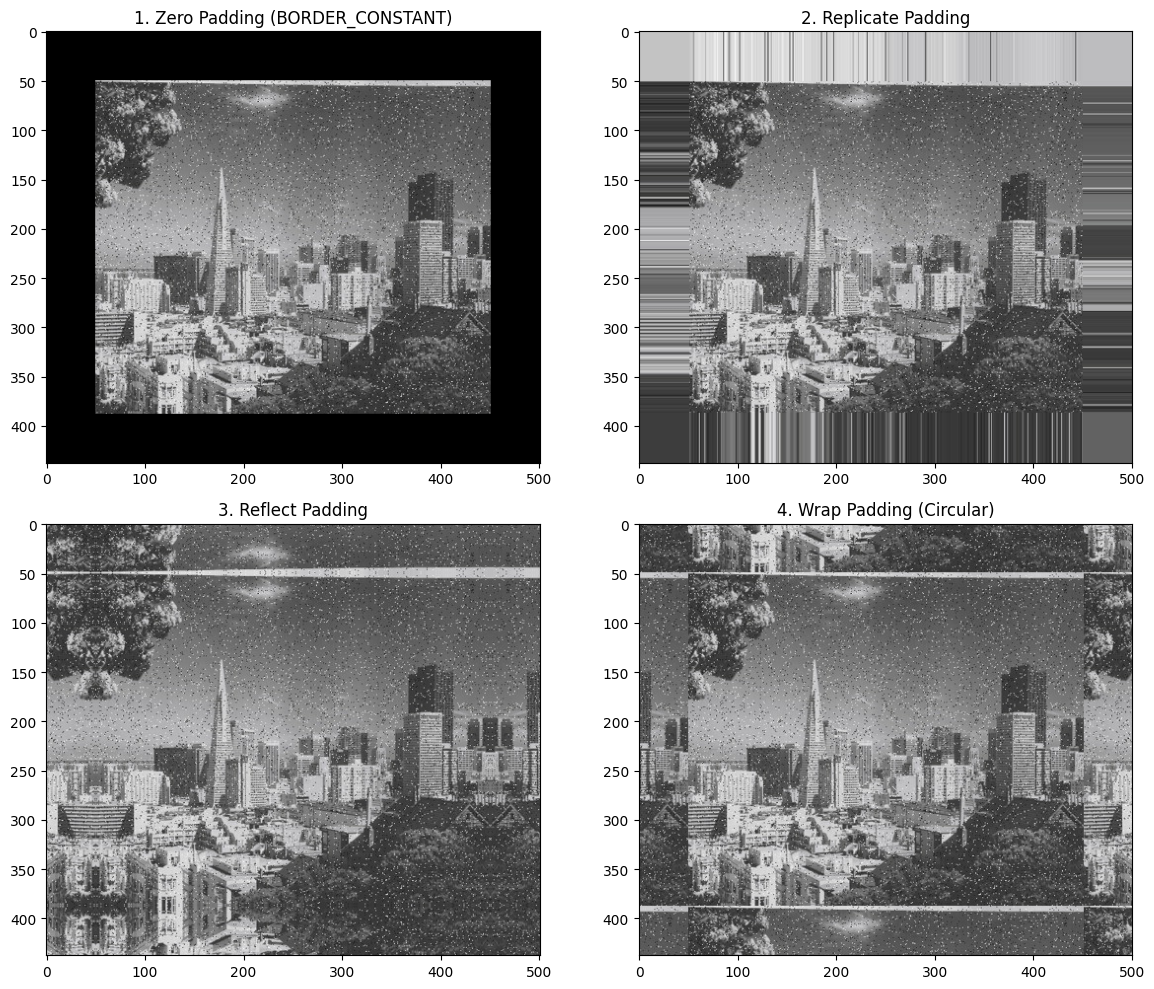

In [9]:
# guided_padding_comparison.py
import cv2
import matplotlib.pyplot as plt
# อ่านภาพต้นฉบับ
img = cv2.imread('imgnoise.jpg') # ใช้คำสั่ง cv2.imread เพื่อโหลดรูปภาพเข้ามาในหน่วยความจำ

# กําหนดขนาดของการทํา Padding รอบทิศทางกว้างขวา 50 พิกเซล
pad_size = 50
# 1. Zero Padding (เติมศูนย์สีดํา)
pad_zero = cv2.copyMakeBorder(img, pad_size, pad_size, pad_size, pad_size,
borderType=cv2.BORDER_CONSTANT, value=[0, 0, 0])
# 2. Replicate Padding (คัดลอกค่าสีริมขอบแผ่แนวตรง)
pad_replicate = cv2.copyMakeBorder(img, pad_size, pad_size, pad_size, pad_size,
borderType=cv2.BORDER_REPLICATE)
# 3. Reflect Padding (สะท้อนย้อนกลับที่ริมขอบ - BORDER_REFLECT_101)
pad_reflect = cv2.copyMakeBorder(img, pad_size, pad_size, pad_size, pad_size,
borderType=cv2.BORDER_REFLECT_101)
# 4. Wrap Padding (คาบสัญญาณวนแบบ Circular)
pad_wrap = cv2.copyMakeBorder(img, pad_size, pad_size, pad_size, pad_size,
borderType=cv2.BORDER_WRAP)
# แปลงสีก่อนแสดงผลร่วมกับ Matplotlib (BGR -> RGB)
pad_zero = cv2.cvtColor(pad_zero, cv2.COLOR_BGR2RGB) # แปลงสเปซสี (Color Space) ของภาพ เช่น BGR เป็น RGB หรือ Grayscale
pad_replicate = cv2.cvtColor(pad_replicate, cv2.COLOR_BGR2RGB) # แปลงสเปซสี (Color Space) ของภาพ เช่น BGR เป็น RGB หรือ Grayscale
pad_reflect = cv2.cvtColor(pad_reflect, cv2.COLOR_BGR2RGB) # แปลงสเปซสี (Color Space) ของภาพ เช่น BGR เป็น RGB หรือ Grayscale
pad_wrap = cv2.cvtColor(pad_wrap, cv2.COLOR_BGR2RGB) # แปลงสเปซสี (Color Space) ของภาพ เช่น BGR เป็น RGB หรือ Grayscale
# แสดงภาพเปรียบเทียบ
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1); plt.imshow(pad_zero); plt.title('1. Zero Padding (BORDER_CONSTANT)') # แสดงผลรูปภาพบนกราฟของ matplotlib
plt.subplot(2, 2, 2); plt.imshow(pad_replicate); plt.title('2. Replicate Padding') # แสดงผลรูปภาพบนกราฟของ matplotlib
plt.subplot(2, 2, 3); plt.imshow(pad_reflect); plt.title('3. Reflect Padding') # แสดงผลรูปภาพบนกราฟของ matplotlib
plt.subplot(2, 2, 4); plt.imshow(pad_wrap); plt.title('4. Wrap Padding (Circular)') # แสดงผลรูปภาพบนกราฟของ matplotlib
plt.tight_layout()
plt.show() # สั่งเรนเดอร์และแสดงกราฟทั้งหมดออกทางหน้าจอ


In [10]:
import cv2
import numpy as np
import time

def manual_averaging_filter(image, kernel_size):
    """
    ฟังก์ชันตัวกรองค่าเฉลี่ยแบบแมนนวล (Manual Box Filter)
    """
    # 1. คำนวณขนาดของการทำ Padding ตามสูตร P = (K - 1) / 2
    P = (kernel_size - 1) // 2
    
    # 2. การจัดการขอบภาพ (Zero Padding) ด้วย cv2.copyMakeBorder
    padded_image = cv2.copyMakeBorder(image, P, P, P, P, 
                                      borderType=cv2.BORDER_CONSTANT, value=0)
    
    # เตรียมอาเรย์ว่างสำหรับเก็บผลลัพธ์ (ขนาดและชนิดข้อมูลเดียวกับภาพต้นฉบับ)
    h, w = image.shape
    output_image = np.zeros((h, w), dtype=np.uint8)
    
    # ตัวหารเฉลี่ย (K^2)
    k_squared = kernel_size * kernel_size
    
    # 3. กลไกการสแกนและคูณสะสม (วนลูป for ซ้อนกัน 2 ชั้น)
    for i in range(h):
        for j in range(w):
            # ดึงพิกเซลเพื่อนบ้านที่อยู่ใต้หน้ากากย่อยขนาด K x K
            # ตำแหน่งใน padded_image จะเลื่อนไปครอบคลุมพื้นที่ [i ถึง i+K, j ถึง j+K]
            region = padded_image[i : i + kernel_size, j : j + kernel_size]
            
            # นำมาบวกรวมกันแล้วหารด้วยตัวหารเฉลี่ย
            # (ใช้ np.sum() ช่วยหาผลรวมในพื้นที่ย่อย ซึ่งถือเป็นคำสั่งพื้นฐานของ NumPy)
            avg_value = np.sum(region) / k_squared
            
            # บันทึกผลลงบนอาเรย์ภาพผลลัพธ์
            output_image[i, j] = np.uint8(avg_value)
            
    return output_image

if __name__ == "__main__":
    # --- ส่วนที่ 4: การเปรียบเทียบประสิทธิภาพเชิงสถิติ ---
    
    # อ่านภาพต้นฉบับ (สมมติว่าใช้ไฟล์ภาพ source.png ในโหมด Grayscale)
    # หากไม่มีไฟล์ สามารถทดสอบด้วยภาพจำลองสุ่ม np.random.randint(0, 256, (500, 500), dtype=np.uint8) ได้
    img = cv2.imread('imgnoise.jpg', cv2.IMREAD_GRAYSCALE) # ใช้คำสั่ง cv2.imread เพื่อโหลดรูปภาพเข้ามาในหน่วยความจำ
    
    if img is None:
        print("ไม่พบไฟล์ 'source.png' จะทำการสร้างภาพจำลองขนาด 500x500 เพื่อทดสอบแทน")
        img = np.random.randint(0, 256, (500, 500), dtype=np.uint8)

    K = 5 # ขนาดหน้ากากตัวอย่าง 5x5
    
    print(f"--- เริ่มต้นเปรียบเทียบประสิทธิภาพการกรอง (Kernel Size: {K}x{K}) ---")
    
    # 1. จับเวลาของ Manual Filter
    start_time_manual = time.time()
    manual_result = manual_averaging_filter(img, K)
    end_time_manual = time.time()
    manual_time = end_time_manual - start_time_manual
    
    # 2. จับเวลาของ OpenCV (cv2.blur)
    start_time_cv2 = time.time()
    cv2_result = cv2.blur(img, (K, K))
    end_time_cv2 = time.time()
    cv2_time = end_time_cv2 - start_time_cv2
    
    # 3. สรุปผล
    print(f"เวลาประมวลผล Manual Filter: {manual_time:.4f} วินาที")
    print(f"เวลาประมวลผล cv2.blur:      {cv2_time:.6f} วินาที")
    
    # ระวังกรณีที่ cv2_time เร็วมากจนเป็น 0 
    if cv2_time > 0:
        speedup = manual_time / cv2_time
        print(f"-> สรุป: cv2.blur ของ OpenCV ทำงานเร็วกว่าประมาณ {speedup:.2f} เท่า")
    else:
        print("-> สรุป: cv2.blur ทำงานเร็วมากจนวัดเวลาเป็น 0.000000 วินาที")

--- เริ่มต้นเปรียบเทียบประสิทธิภาพการกรอง (Kernel Size: 5x5) ---
เวลาประมวลผล Manual Filter: 0.4135 วินาที
เวลาประมวลผล cv2.blur:      0.000157 วินาที
-> สรุป: cv2.blur ของ OpenCV ทำงานเร็วกว่าประมาณ 2635.89 เท่า


In [13]:
import cv2
import numpy as np
import time 

def manual_averaging_filter(image, kernel_size):
    K = kernel_size
    # ใช้ // (integer division) เพราะ K เป็นเลขคี่เสมอ (3 หรือ 5) ดังนั้น (K-1) จะหารด้วย 2 ลงตัวพอดี
    P = (K - 1) // 2 

    padding_image = cv2.copyMakeBorder(
        image,
        top = P , bottom = P , left = P , right = P ,
        borderType = cv2.BORDER_CONSTANT , 
        value = 0
    )

    height , wight = image.shape # ของรูปต้นฉบับ
    output_image = np.zeros((height, wight), dtype = np.uint8) # เตรียมภาพเปล่าๆ

    for i in range(height): # แนวแถว
        for j in range(wight): # แนวคอลัม
            # ตำแหน่งพิกเซล (i,j) เดิม อยู่ที่ (i+P, j+P) ในภาพ pad แล้ว
            center_row = i + P
            center_col = j + P

            # ตัดหน้าต่าง K x K รอบพิกเซลนี้ออกมา
            window = padding_image[
                center_row - P : center_row + P + 1 ,
                center_col - P : center_col + P + 1 ,
            ]

            # รวมค่าพิกเซลทั้งหมดในหน้าต่าง แล้วหารด้วย K^2
            total = 0 
            for m in range(K):
                for n in range(K):
                    total += int(window[m , n]) # ใช้ int กันค่า overflow ตอนบวก

            average_value = total // (K * K)

            output_image[i , j] = average_value
            
    return output_image

# ส่วนทดสอบ + วัดเวลาเปรียบเทียบกับ cv2.blur()
if __name__ == "__main__":

    # โหลดภาพจริง แปลงเป็น grayscale
    image = cv2.imread('imgnoise.jpg', cv2.IMREAD_GRAYSCALE) # ใช้คำสั่ง cv2.imread เพื่อโหลดรูปภาพเข้ามาในหน่วยความจำ

    if image is None:
        raise FileNotFoundError("ไม่พบไฟล์ภาพ กรุณาตรวจสอบ path ของไฟล์")

    kernel_sizes = [3, 5]

    for K in kernel_sizes:
        print(f"===== Kernel size: {K}x{K} =====")

        # ---- วัดเวลาโค้ด manual ----
        start_time = time.time()
        manual_result = manual_averaging_filter(image, K)
        end_time = time.time()
        manual_time = end_time - start_time

        # ---- วัดเวลา cv2.blur() ----
        start_time = time.time()
        cv2_result = cv2.blur(image, (K, K))
        end_time = time.time()
        cv2_time = end_time - start_time

        # ---- แสดงผลเปรียบเทียบ ----
        print(f"Manual averaging filter time : {manual_time:.6f} วินาที")
        print(f"cv2.blur() time              : {cv2_time:.6f} วินาที")
        print(f"Manual ช้ากว่า cv2.blur() ประมาณ {manual_time / cv2_time:.1f} เท่า")
        print()

        # ---- บันทึกภาพผลลัพธ์ ----
        cv2.imwrite(f'manual_result_k{K}.png', manual_result)
        cv2.imwrite(f'cv2_result_k{K}.png', cv2_result)

    print("เสร็จสิ้น: บันทึกภาพผลลัพธ์ทั้งหมดเรียบร้อยแล้ว")

===== Kernel size: 3x3 =====
Manual averaging filter time : 0.223437 วินาที
cv2.blur() time              : 0.004289 วินาที
Manual ช้ากว่า cv2.blur() ประมาณ 52.1 เท่า

===== Kernel size: 5x5 =====
Manual averaging filter time : 0.475868 วินาที
cv2.blur() time              : 0.000226 วินาที
Manual ช้ากว่า cv2.blur() ประมาณ 2105.4 เท่า

เสร็จสิ้น: บันทึกภาพผลลัพธ์ทั้งหมดเรียบร้อยแล้ว


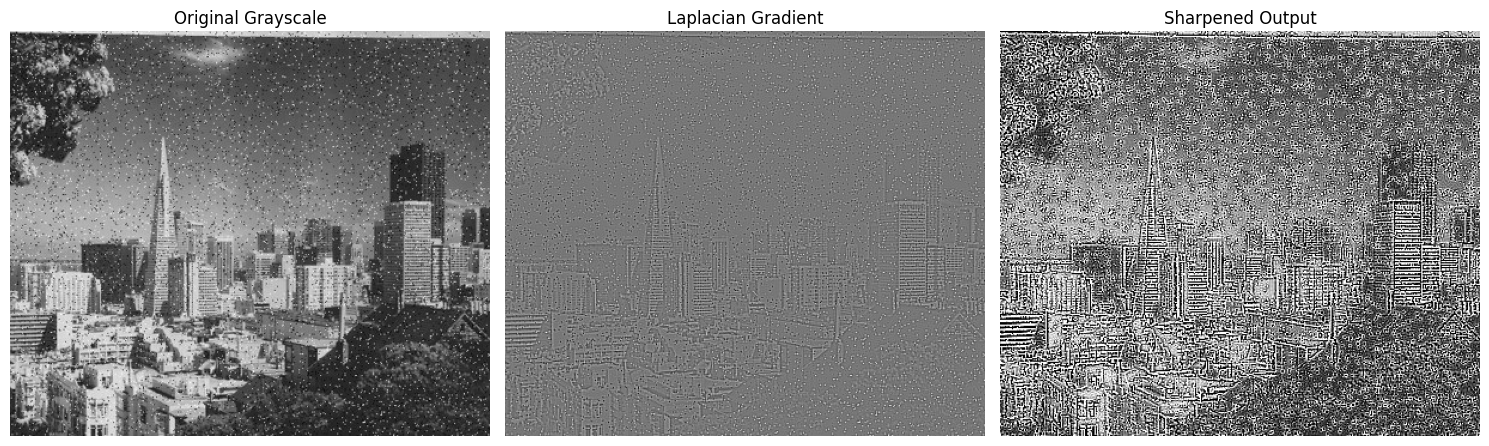

True

In [16]:
# อ่านไฟล์ภาพสี แล้วแปลงเป็นภาพระดับสีเทา
image_color = cv2.imread('imgnoise.jpg') # ใช้คำสั่ง cv2.imread เพื่อโหลดรูปภาพเข้ามาในหน่วยความจำ
gray_image = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY) # แปลงสเปซสี (Color Space) ของภาพ เช่น BGR เป็น RGB หรือ Grayscale

laplacian_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

laplacian_gradient = cv2.filter2D(gray_image, cv2.CV_64F, laplacian_kernel) # ใช้ cv2.filter2D นำเคอร์เนลมาคอนโวลูชันกับภาพ

sharpened_image = gray_image.astype(np.float64) - laplacian_gradient

sharpened_image = np.clip(sharpened_image, 0, 255) # ใช้ np.clip จำกัดค่าพิกเซลไม่ให้ต่ำกว่า 0 หรือเกิน 255
sharpened_image = sharpened_image.astype(np.uint8)

# ---- Plot เปรียบเทียบ 3 ภาพ ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ภาพที่ 1: ภาพสีเทาต้นฉบับ
axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

# ภาพที่ 2: ภาพเกรเดียนต์ Laplacian (ขอบเขต)
axes[1].imshow(laplacian_gradient, cmap='gray')
axes[1].set_title('Laplacian Gradient')
axes[1].axis('off')

# ภาพที่ 3: ภาพคมชัดที่ได้ (ผลลัพธ์สุดท้าย)
axes[2].imshow(sharpened_image, cmap='gray')
axes[2].set_title('Sharpened Output')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('comparison_plot.png')   # (ทางเลือก) บันทึกภาพเปรียบเทียบทั้ง 3 ช่องเก็บไว้ด้วย
plt.show() # สั่งเรนเดอร์และแสดงกราฟทั้งหมดออกทางหน้าจอ

# ---- บันทึกเฉพาะภาพคมชัดผลลัพธ์สุดท้าย ตามชื่อที่โจทย์กำหนด ----
cv2.imwrite('sharpened_output.png', sharpened_image)